In [2]:
import warnings


warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pm4py
from pm4py.objects.conversion.log import converter as log_converter

In [3]:
def load_log(path: str):
    log_df = pm4py.read_xes(path)
    log = log_converter.apply(log_df)
    return log, log_df


def get_unique_events(log_df: pd.DataFrame):
    return sorted(log_df['concept:name'].unique())


def get_trace_length(log_df: pd.DataFrame):
    trace_lengths = log_df.groupby('case:concept:name').size()
    return trace_lengths.tolist()


def get_trace_duration(log_df: pd.DataFrame):
    trace_durations = log_df.groupby('case:concept:name')['time:timestamp'].agg(
        ['min', 'max']
    )
    trace_durations['duration'] = (
        trace_durations['max'] - trace_durations['min']
    ).dt.total_seconds()
    return trace_durations['duration'].tolist()

In [19]:
def get_trace_length_distribution(log_df: pd.DataFrame, dataset_name: str):
    lengths = get_trace_length(log_df)

    plt.figure(figsize=(10, 6))
    plt.hist(
        lengths,
        bins=range(min(lengths), max(lengths) + 2),
        color='skyblue',
        edgecolor='black',
        alpha=0.7,
    )

    percentiles = [
        {
            'label': '80% Percentile',
            'value': np.percentile(lengths, 80),
            'color': 'red',
            'linestyle': 'dashed',
        },
        {
            'label': '90% Percentile',
            'value': np.percentile(lengths, 90),
            'color': 'orange',
            'linestyle': 'dashed',
        },
        {
            'label': '95% Percentile',
            'value': np.percentile(lengths, 95),
            'color': 'purple',
            'linestyle': 'dashed',
        },
        {
            'label': 'Median',
            'value': np.median(lengths),
            'color': 'green',
            'linestyle': 'dotted',
        },
    ]

    for p in percentiles:
        plt.axvline(
            p['value'],
            color=p['color'],
            linestyle=p['linestyle'],
            linewidth=2,
            label=f'{p["label"]} ({int(p["value"])})',
        )

    plt.title(f'Trace Length Distribution: {dataset_name}')
    plt.xlabel('Number of Events (Trace Length)')
    plt.ylabel('Frequency (Number of Traces)')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()


def get_trace_duration_distribution(log_df: pd.DataFrame, dataset_name: str):
    durations = get_trace_duration(log_df)

    plt.figure(figsize=(10, 6))
    plt.hist(
        durations,
        bins=10,
        color='lightcoral',
        edgecolor='black',
        alpha=0.7,
    )

    percentiles = [
        {
            'label': '80% Percentile',
            'value': np.percentile(durations, 80),
            'color': 'red',
            'linestyle': 'dashed',
        },
        {
            'label': '90% Percentile',
            'value': np.percentile(durations, 90),
            'color': 'orange',
            'linestyle': 'dashed',
        },
        {
            'label': '95% Percentile',
            'value': np.percentile(durations, 95),
            'color': 'purple',
            'linestyle': 'dashed',
        },
        {
            'label': 'Median',
            'value': np.median(durations),
            'color': 'green',
            'linestyle': 'dotted',
        },
    ]

    for p in percentiles:
        plt.axvline(
            p['value'],
            color=p['color'],
            linestyle=p['linestyle'],
            linewidth=2,
            label=f'{p["label"]} ({int(p["value"]):,}s)',
        )

    plt.title(f'Trace Duration Distribution: {dataset_name}')
    plt.xlabel('Duration (Seconds)')
    plt.ylabel('Frequency (Number of Traces)')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()

In [7]:
dataset_name = 'BPIC_20_DD'
dataset_path = f'../../../datasets/raw/{dataset_name}.xes'

log, log_df = load_log(dataset_path)

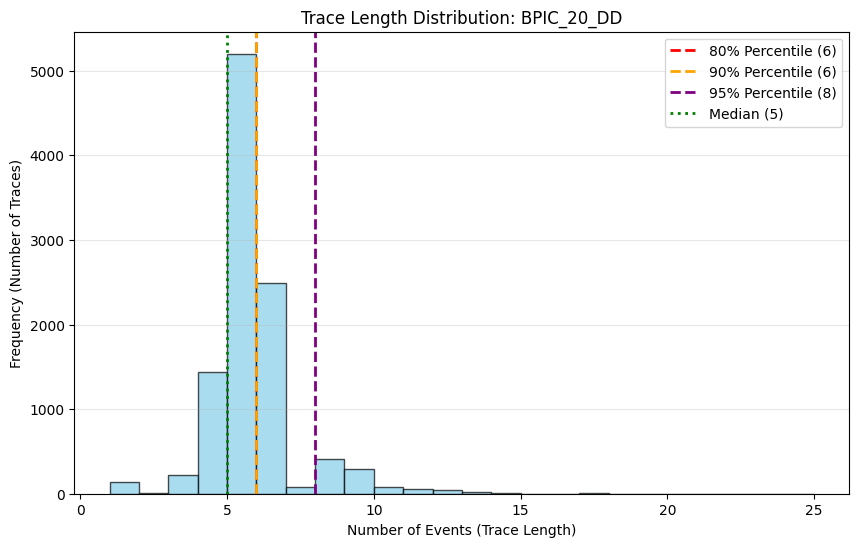

In [8]:
get_trace_length_distribution(log_df, dataset_name)

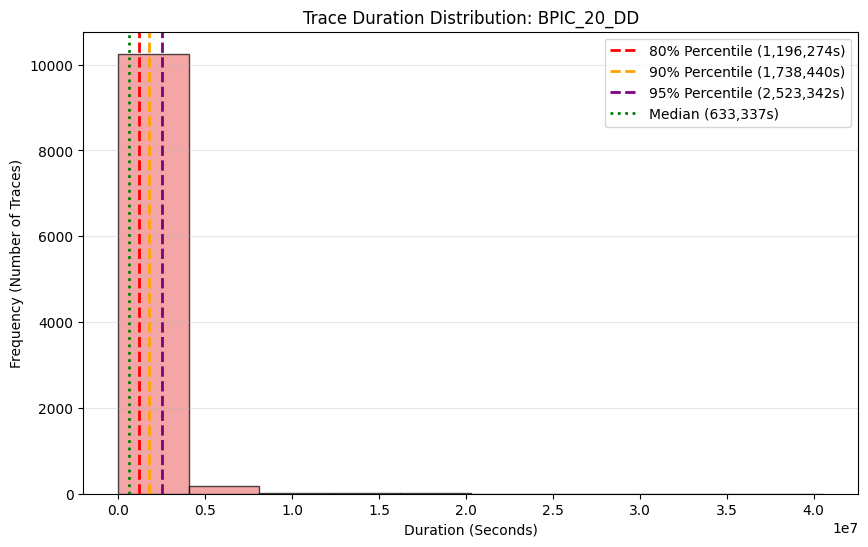

In [20]:
get_trace_duration_distribution(log_df, dataset_name)